In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
print(os.getcwd())

d:\Projects\Predictive-Maintenance\notebooks


In [3]:

import pandas as pd
from config.paths import CSV_DATASET

df = pd.read_csv(CSV_DATASET)

In [4]:
from config.paths import PLOTS

In [5]:
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

In [6]:
print(df.shape)

(10000, 14)


In [7]:
print(df.dtypes)

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [8]:
print(df.isnull().sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [9]:
print(df.duplicated().sum())

0


# Data Sanity Check 

## Summary

- **Shape:** 10,000 rows × 14 columns
- **Missing values:** None - 0 nulls across all columns
- **Duplicate rows:** None - 0 exact duplicates
- **Data types:** Correct as expected
  - `Product ID`, `Type` -> string
  - `UDI`, `Rotational speed`, `Tool wear`, `Machine failure`, and failure flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) -> int64
  - `Air temperature`, `Process temperature`, `Torque` -> float64

## Columns

| Column | Type | Notes |
|---|---|---|
| UDI | int64 | Row identifier (1–10000), likely non-predictive |
| Product ID | string | Unique per row, likely non-predictive |
| Type | string | Categorical: L / M / H |
| Air temperature [K] | float64 | Sensor reading |
| Process temperature [K] | float64 | Sensor reading |
| Rotational speed [rpm] | int64 | Sensor reading |
| Torque [Nm] | float64 | Sensor reading |
| Tool wear [min] | int64 | Sensor reading |
| Machine failure | int64 | Target variable (binary) |
| TWF, HDF, PWF, OSF, RNF | int64 | Individual failure mode flags |

## Decisions

- Dataset arrived clean - no imputation or deduplication needed.
- `UDI` and `Product ID` are candidates to drop before modeling (non-predictive identifiers).
- `Type` will need encoding before modeling.


In [10]:
print(df['UDI'].nunique())
print(df['Product ID'].nunique())
print(df['Type'].nunique())

10000
10000
3


## Cardinality Check
 
- `UDI`: 10,000 unique values -> pure row index, non-predictive
- `Product ID`: 10,000 unique values -> pure identifier, non-predictive
- `Type`: 3 unique values (L, M, H) -> categorical, keep


In [11]:
print(df['Type'].value_counts())
print(df['Type'].value_counts(normalize=True))

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
Type
L    0.6000
M    0.2997
H    0.1003
Name: proportion, dtype: float64


In [12]:
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True))

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


## Type Distribution
 
| Type | Count | Proportion |
|---|---|---|
| L | 6000 | 60.0% |
| M | 2997 | 29.97% |
| H | 1003 | 10.03% |
 
## Target Distribution (Machine failure)
 
| Class | Count | Proportion |
|---|---|---|
| 0 (No failure) | 9661 | 96.61% |
| 1 (Failure) | 339 | 3.39% |
 
**Key finding:** Severe class imbalance (~29:1 ratio). This confirms accuracy is not a suitable evaluation metric, a model predicting "no failure" for every row would score 96.61% accuracy while being useless. This drives the decision to use class weighting (or SMOTE as a comparison) and to evaluate with precision/recall/F1/PR-AUC on the failure class.
 
## Decisions

- Class imbalance confirmed — use class weighting / PR-AUC-based evaluation rather than accuracy.


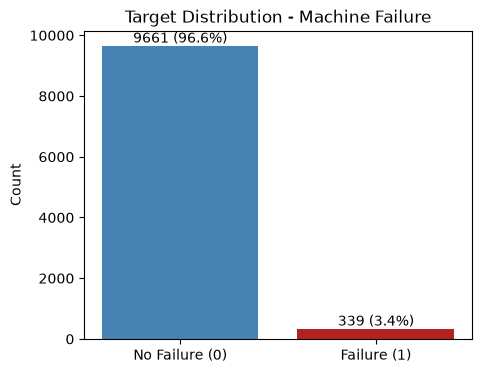

In [13]:
import matplotlib.pyplot as plt

counts = df['Machine failure'].value_counts()
plt.figure(figsize=(5,4))
plt.bar(['No Failure (0)', 'Failure (1)'], counts.values, color=['steelblue', 'firebrick'])
plt.title('Target Distribution - Machine Failure')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 100, f'{v} ({v/len(df)*100:.1f}%)', ha='center')
plt.savefig(PLOTS / "Target_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

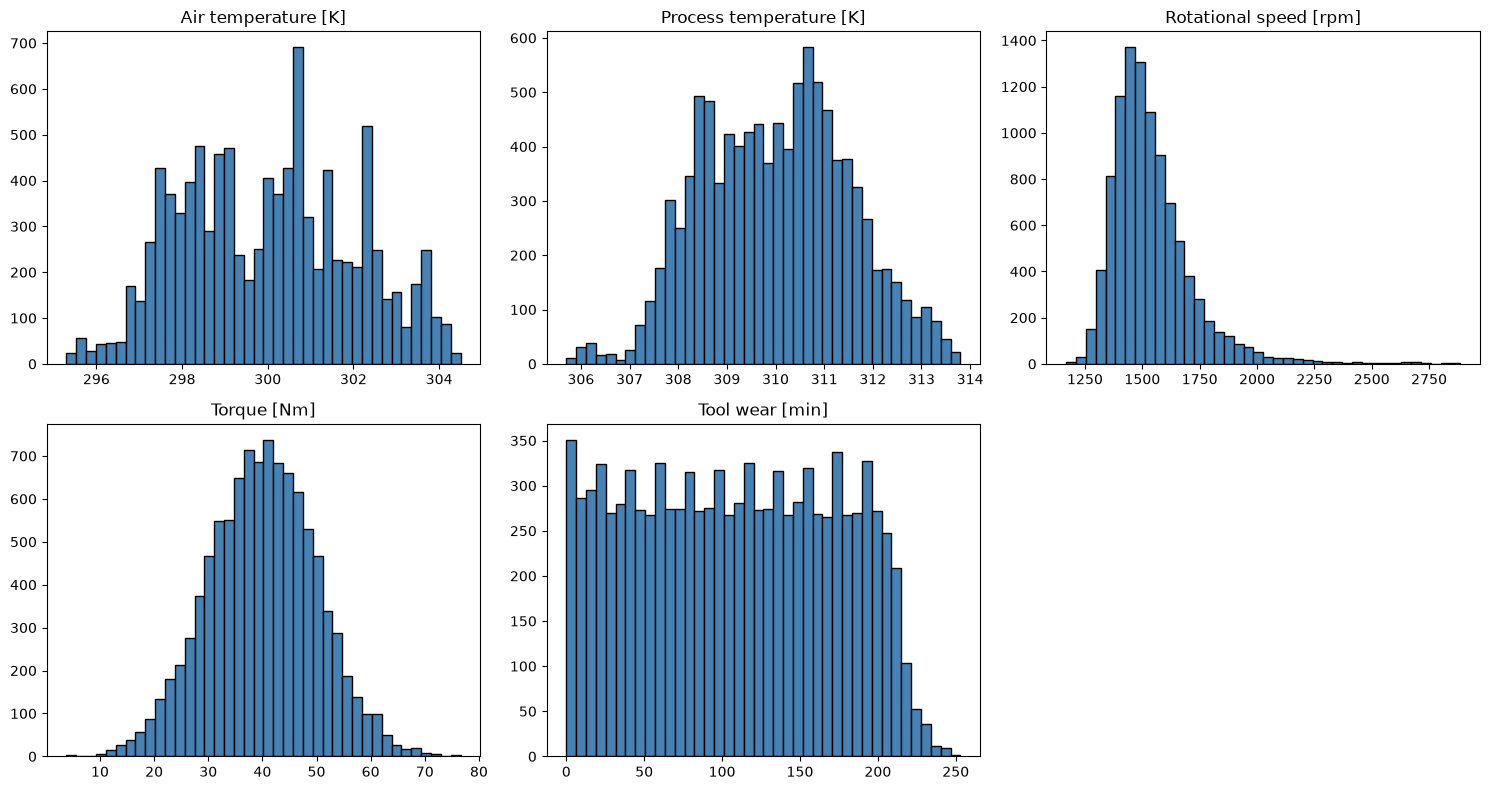

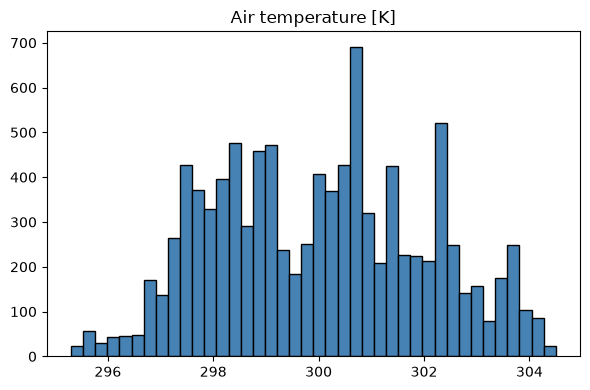

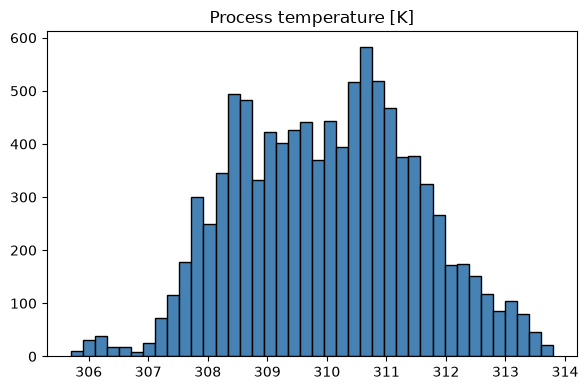

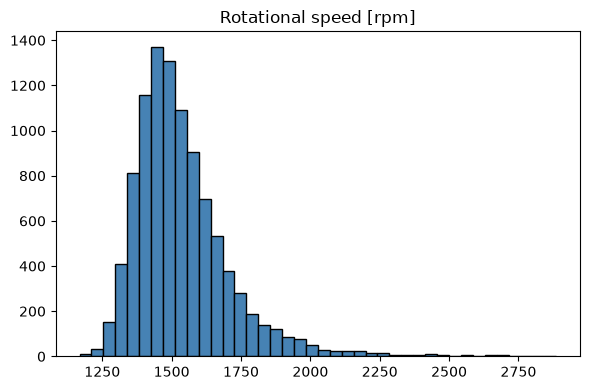

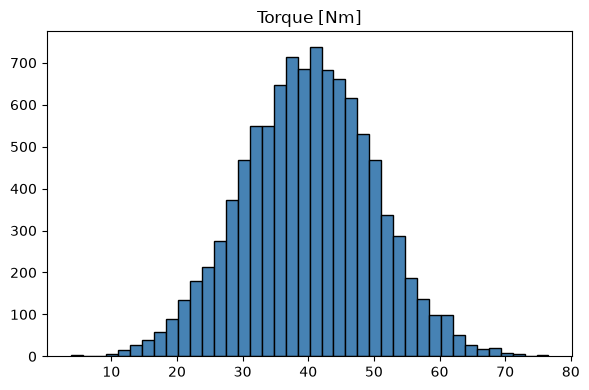

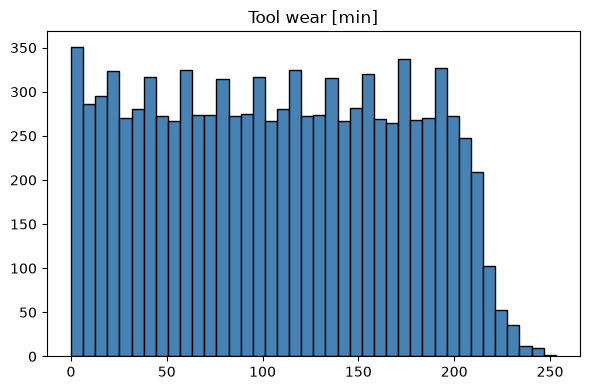

In [14]:
numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black')
    axes[i].set_title(col)

axes[-1].axis('off')  
plt.tight_layout()
plt.savefig(PLOTS / "numeric_distributions_combined.png", dpi=300, bbox_inches="tight")
plt.show()

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=40, color='steelblue', edgecolor='black')
    plt.title(col)
    plt.tight_layout()

    safe_name = col.split(' [')[0].replace(' ', '_') 
    plt.savefig(PLOTS / f"distribution_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

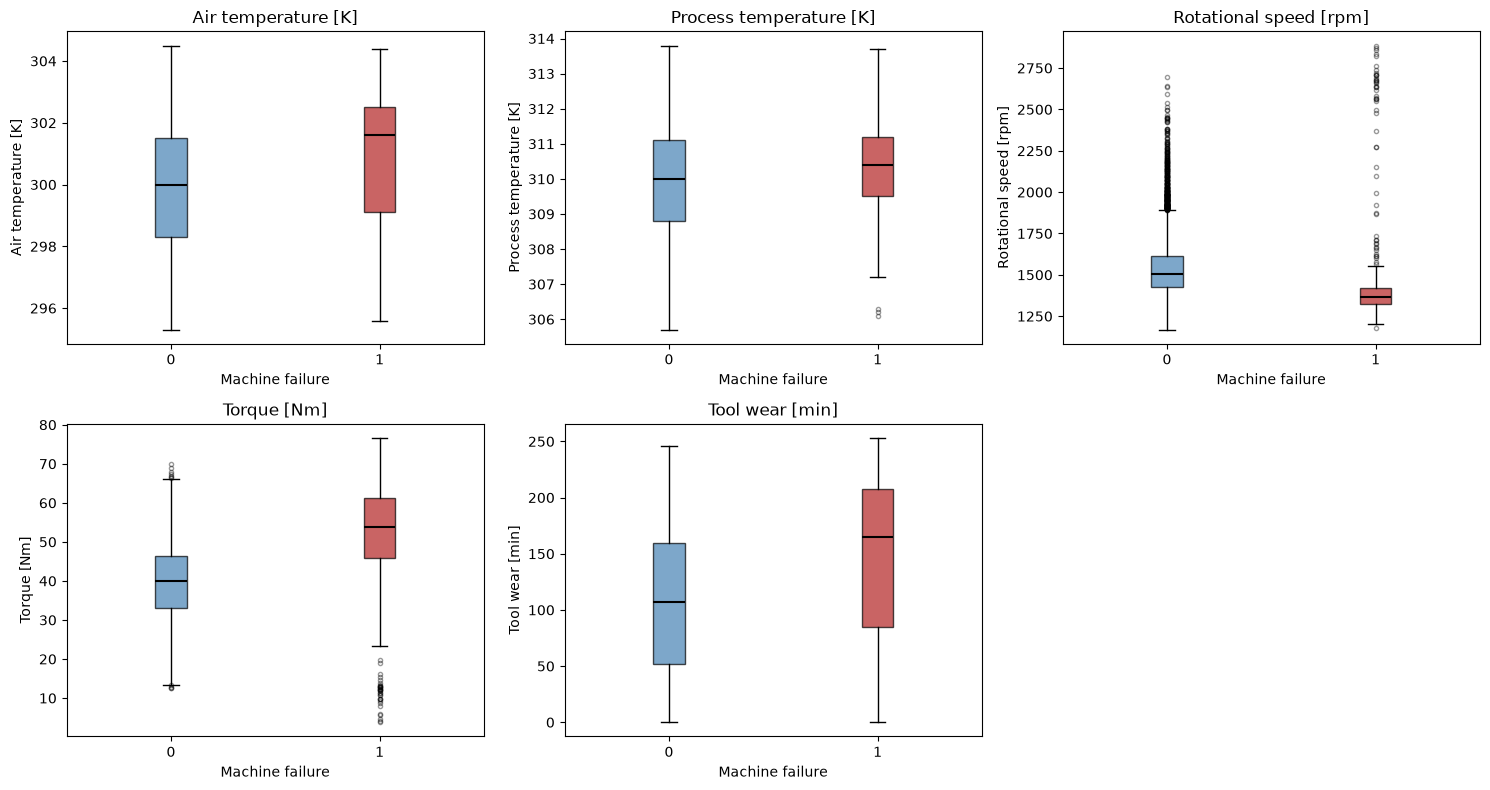

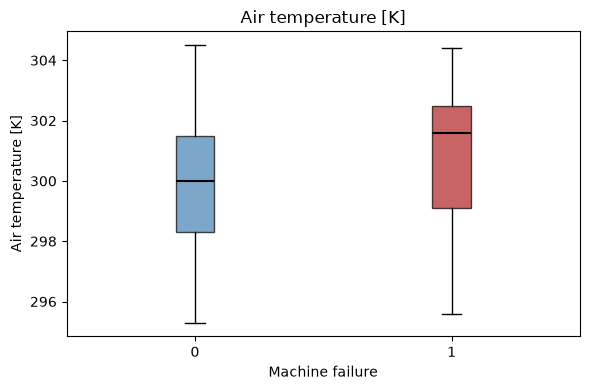

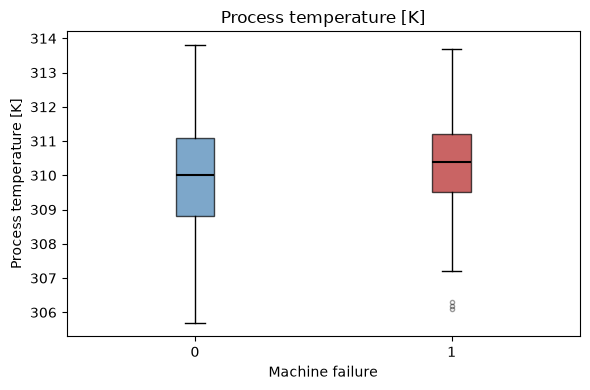

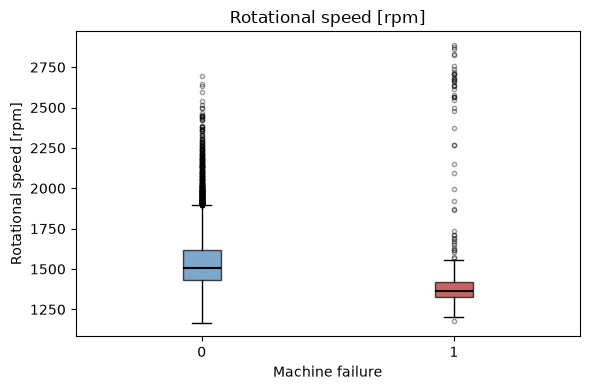

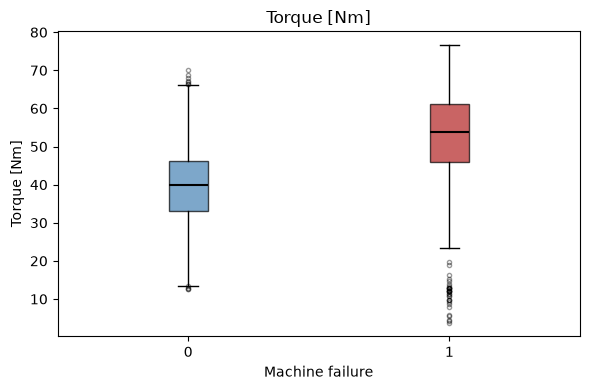

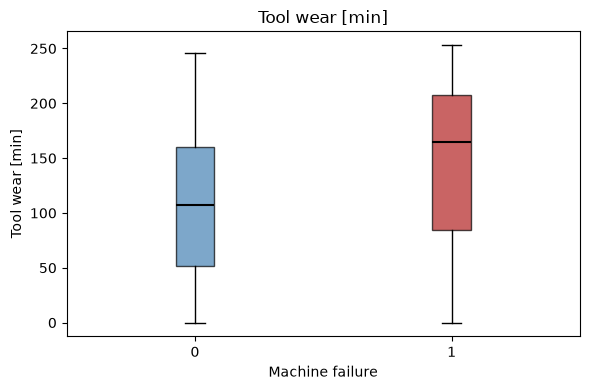

In [15]:
colors = {0: 'steelblue', 1: 'firebrick'}
groups = [0, 1]

def colored_boxplot(ax, col):
    data = [df[df['Machine failure'] == g][col].values for g in groups]
    try:
        bp = ax.boxplot(data, patch_artist=True, tick_labels=['0', '1'],
                        medianprops=dict(color='black', linewidth=1.5),
                        flierprops=dict(marker='o', markersize=3, alpha=0.4))
    except TypeError:
        bp = ax.boxplot(data, patch_artist=True, labels=['0', '1'],
                        medianprops=dict(color='black', linewidth=1.5),
                        flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, g in zip(bp['boxes'], groups):
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.7)
    ax.set_title(col)
    ax.set_xlabel('Machine failure')
    ax.set_ylabel(col)

# --- Combined figure ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    colored_boxplot(axes[i], col)

axes[-1].axis('off')
plt.tight_layout()
plt.savefig(PLOTS / "boxplots_by_failure_combined.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Individual figures ---
for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(6, 4))
    colored_boxplot(ax, col)
    plt.tight_layout()

    safe_name = col.split(' [')[0].replace(' ', '_')
    plt.savefig(PLOTS / f"boxplot_{safe_name}_by_failure.png", dpi=300, bbox_inches="tight")
    plt.show()

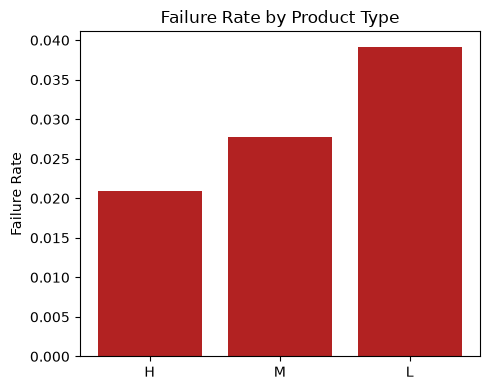

In [16]:
failure_rate_by_type = df.groupby('Type')['Machine failure'].mean().sort_values()

plt.figure(figsize=(5,4))
plt.bar(failure_rate_by_type.index, failure_rate_by_type.values, color='firebrick')
plt.title('Failure Rate by Product Type')
plt.ylabel('Failure Rate')
plt.tight_layout()
plt.savefig(PLOTS / "failure_rate_by_type.png", dpi=300, bbox_inches="tight")
plt.show()

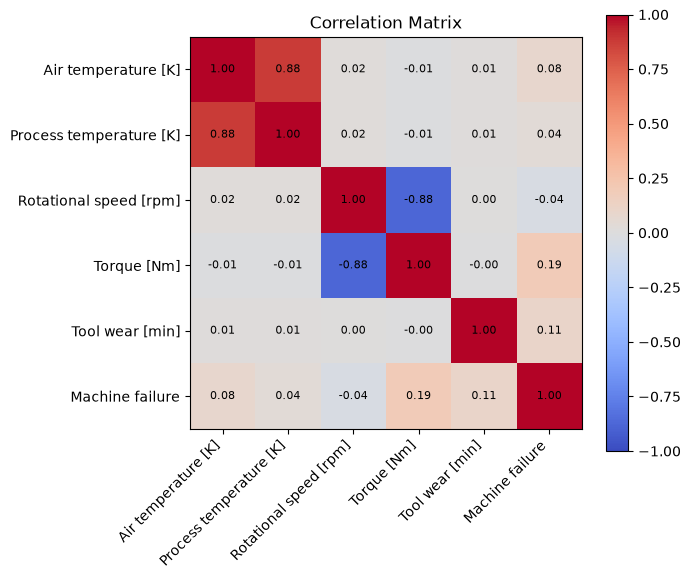

In [17]:
import numpy as np

corr = df[numeric_cols + ['Machine failure']].corr()

plt.figure(figsize=(7,6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(PLOTS / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

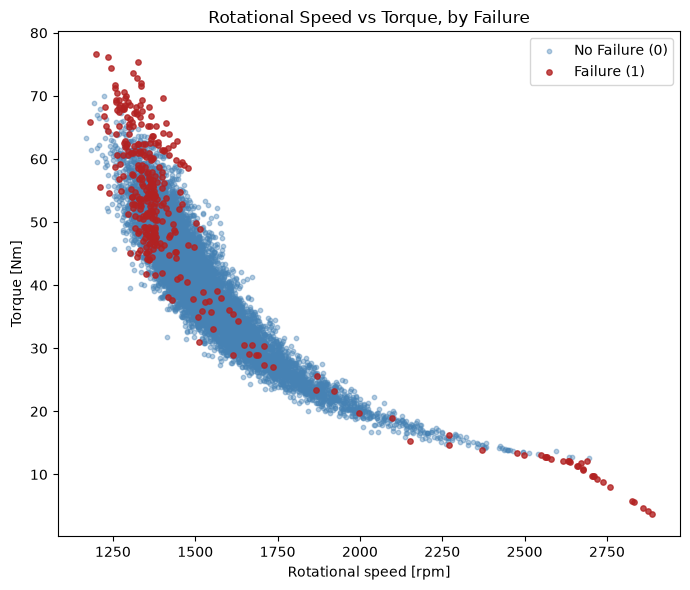

In [18]:
no_fail = df[df['Machine failure'] == 0]
fail = df[df['Machine failure'] == 1]

plt.figure(figsize=(7, 6))
plt.scatter(no_fail['Rotational speed [rpm]'], no_fail['Torque [Nm]'],
            s=10, alpha=0.4, color='steelblue', label='No Failure (0)')
plt.scatter(fail['Rotational speed [rpm]'], fail['Torque [Nm]'],
            s=15, alpha=0.8, color='firebrick', label='Failure (1)')

plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.title('Rotational Speed vs Torque, by Failure')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS / "scatter_speed_vs_torque_by_failure.png", dpi=300, bbox_inches="tight")
plt.show()

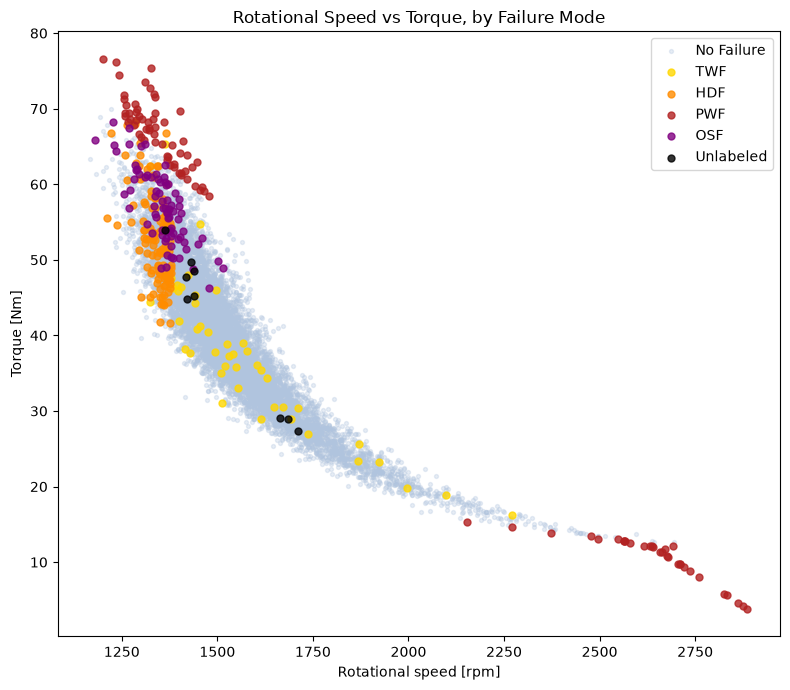

failure_mode
No Failure    9661
HDF            115
PWF             91
OSF             78
TWF             46
Unlabeled        9
Name: count, dtype: int64


In [19]:
failure_flags = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

def get_failure_mode(row):
    if row['Machine failure'] == 0:
        return 'No Failure'
    for flag in failure_flags:
        if row[flag] == 1:
            return flag
    return 'Unlabeled' 

df['failure_mode'] = df.apply(get_failure_mode, axis=1)

mode_colors = {
    'No Failure': 'lightsteelblue',
    'TWF': 'gold',
    'HDF': 'darkorange',
    'PWF': 'firebrick',
    'OSF': 'purple',
    'RNF': 'green',
    'Unlabeled': 'black'
}

plt.figure(figsize=(8, 7))

for mode in ['No Failure'] + [m for m in mode_colors if m != 'No Failure']:
    subset = df[df['failure_mode'] == mode]
    if len(subset) == 0:
        continue
    alpha = 0.3 if mode == 'No Failure' else 0.8
    size = 8 if mode == 'No Failure' else 25
    plt.scatter(subset['Rotational speed [rpm]'], subset['Torque [Nm]'],
                s=size, alpha=alpha, color=mode_colors[mode], label=mode)

plt.xlabel('Rotational speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.title('Rotational Speed vs Torque, by Failure Mode')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS / "scatter_speed_vs_torque_by_failure_mode.png", dpi=300, bbox_inches="tight")
plt.show()

print(df['failure_mode'].value_counts())